In [1]:
print("Hello Jupyter")

Hello Jupyter


In [1]:
import os

print(os.getcwd())

c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\notebooks


In [2]:
import os

dataset_path = "../data/WESAD"

print(os.path.exists(dataset_path))


True


In [3]:
import os

dataset_path = "../data/WESAD"

print(os.listdir(dataset_path)[:10])

['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4']


In [4]:
import pickle

file_path = "../data/WESAD/S2/S2.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("Loaded Successfully")

Loaded Successfully


In [5]:
print(data.keys())

dict_keys(['signal', 'label', 'subject'])


In [6]:
print(data['signal'].keys())

dict_keys(['chest', 'wrist'])


In [7]:
print(data['signal']['chest'].keys())

dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [9]:
ECG = data['signal']['chest']['ECG']
PPG = data['signal']['wrist']['BVP']
EDA = data['signal']['wrist']['EDA']
labels = data['label']

print("ECG Shape :", ECG.shape)
print("PPG Shape :", PPG.shape)
print("EDA Shape :", EDA.shape)
print("Labels Shape :", labels.shape)

ECG Shape : (4255300, 1)
PPG Shape : (389056, 1)
EDA Shape : (24316, 1)
Labels Shape : (4255300,)


In [10]:
import neurokit2 as nk

print(nk.__version__)

0.2.13


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import neurokit2 as nk

from scipy.signal import butter, filtfilt, welch
from scipy.stats import entropy

## 2. Load WESAD Subject

In [2]:
file_path = "../data/WESAD/S2/S2.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("Loaded Successfully")

Loaded Successfully


In [3]:
ecg = data['signal']['chest']['ECG'].flatten()
ppg = data['signal']['wrist']['BVP'].flatten()
eda = data['signal']['wrist']['EDA'].flatten()
labels = data['label'].flatten()

print(ecg.shape)
print(ppg.shape)
print(eda.shape)
print(labels.shape)

(4255300,)
(389056,)
(24316,)
(4255300,)


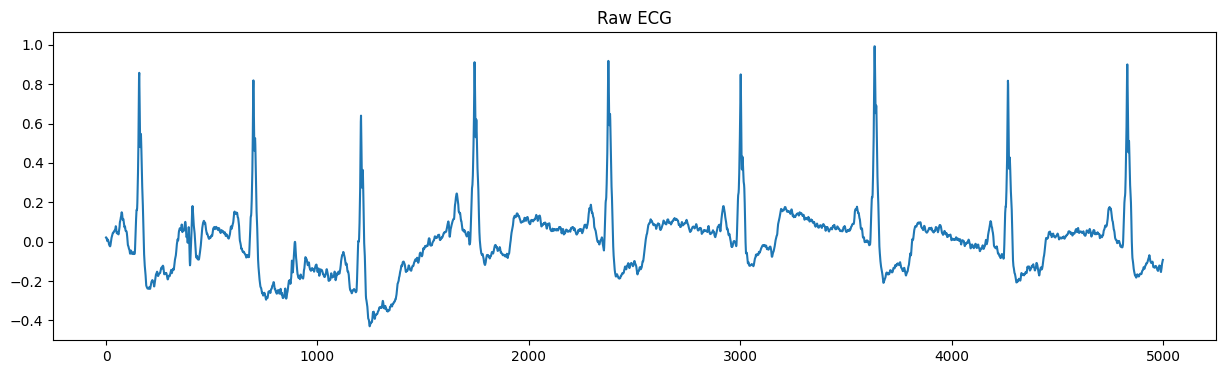

In [14]:
plt.figure(figsize=(15,4))
plt.plot(ecg[:5000])
plt.title("Raw ECG")
plt.show()

In [15]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    filtered = filtfilt(
        b,
        a,
        signal
    )

    return filtered

In [16]:
ecg_filtered = bandpass_filter(
    ecg,
    lowcut=0.5,
    highcut=40,
    fs=700
)

print(ecg_filtered.shape)

(4255300,)


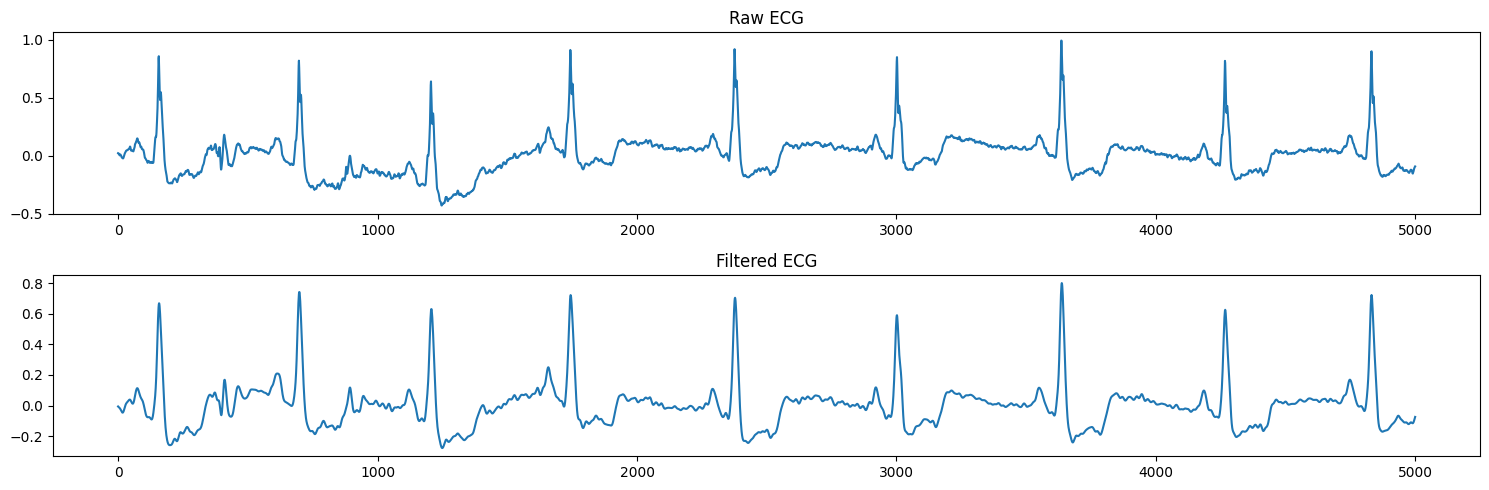

In [17]:
plt.figure(figsize=(15,5))

plt.subplot(2,1,1)
plt.plot(ecg[:5000])
plt.title("Raw ECG")

plt.subplot(2,1,2)
plt.plot(ecg_filtered[:5000])
plt.title("Filtered ECG")

plt.tight_layout()
plt.show()

In [18]:
import pywt
import numpy as np


In [19]:
def wavelet_denoise(signal,
                    wavelet='db4',
                    level=6):

    coeffs = pywt.wavedec(
        signal,
        wavelet,
        level=level
    )

    sigma = np.median(
        np.abs(coeffs[-1])
    ) / 0.6745

    threshold = sigma * np.sqrt(
        2 * np.log(len(signal))
    )

    coeffs[1:] = [
        pywt.threshold(
            c,
            threshold,
            mode='soft'
        )
        for c in coeffs[1:]
    ]

    denoised = pywt.waverec(
        coeffs,
        wavelet
    )

    return denoised[:len(signal)]

In [20]:
ecg_denoised = wavelet_denoise(
    ecg_filtered
)

print(ecg_denoised.shape)

(4255300,)


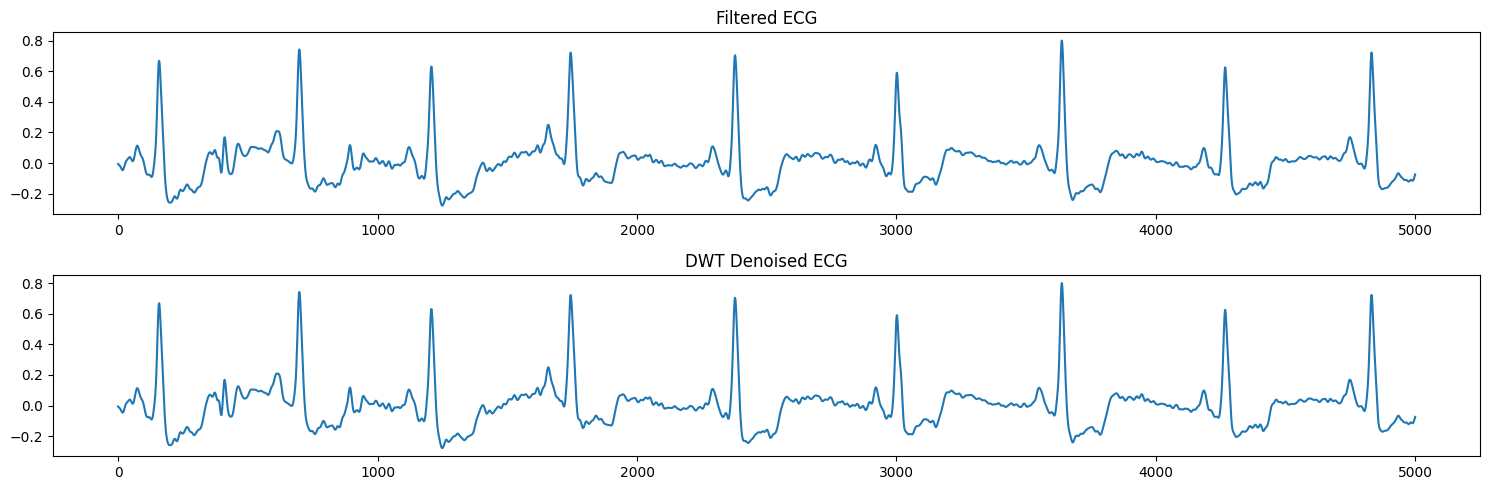

In [21]:
plt.figure(figsize=(15,5))

plt.subplot(2,1,1)
plt.plot(ecg_filtered[:5000])
plt.title("Filtered ECG")

plt.subplot(2,1,2)
plt.plot(ecg_denoised[:5000])
plt.title("DWT Denoised ECG")

plt.tight_layout()
plt.show()

In [22]:
print("Raw ECG")
print(np.std(ecg))

print("\nFiltered ECG")
print(np.std(ecg_filtered))

print("\nDenoised ECG")
print(np.std(ecg_denoised))

Raw ECG
0.15407729615295931

Filtered ECG
0.15099018286955915

Denoised ECG
0.1509790634666229


## PPG Bandpass Filtering

In [23]:
ppg_filtered = bandpass_filter(
    ppg,
    lowcut=0.5,
    highcut=8,
    fs=64
)

print(ppg_filtered.shape)

(389056,)


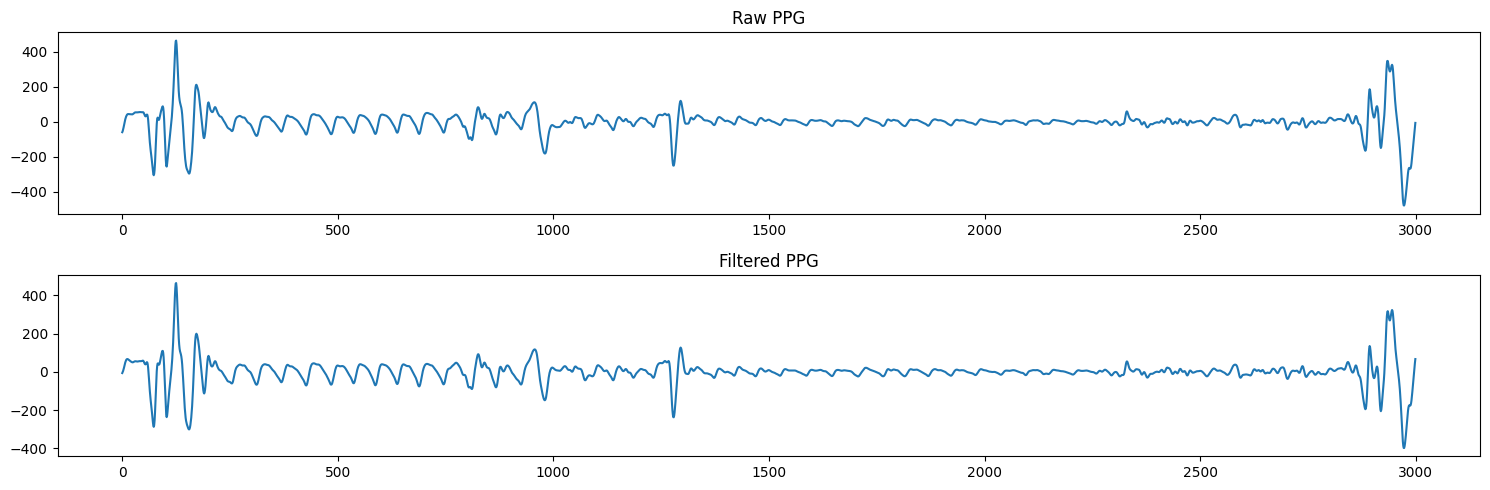

In [24]:
plt.figure(figsize=(15,5))

plt.subplot(2,1,1)
plt.plot(ppg[:3000])
plt.title("Raw PPG")

plt.subplot(2,1,2)
plt.plot(ppg_filtered[:3000])
plt.title("Filtered PPG")

plt.tight_layout()
plt.show()

In [25]:
ppg_denoised = wavelet_denoise(
    ppg_filtered,
    wavelet='db4',
    level=5
)

print(ppg_denoised.shape)

(389056,)


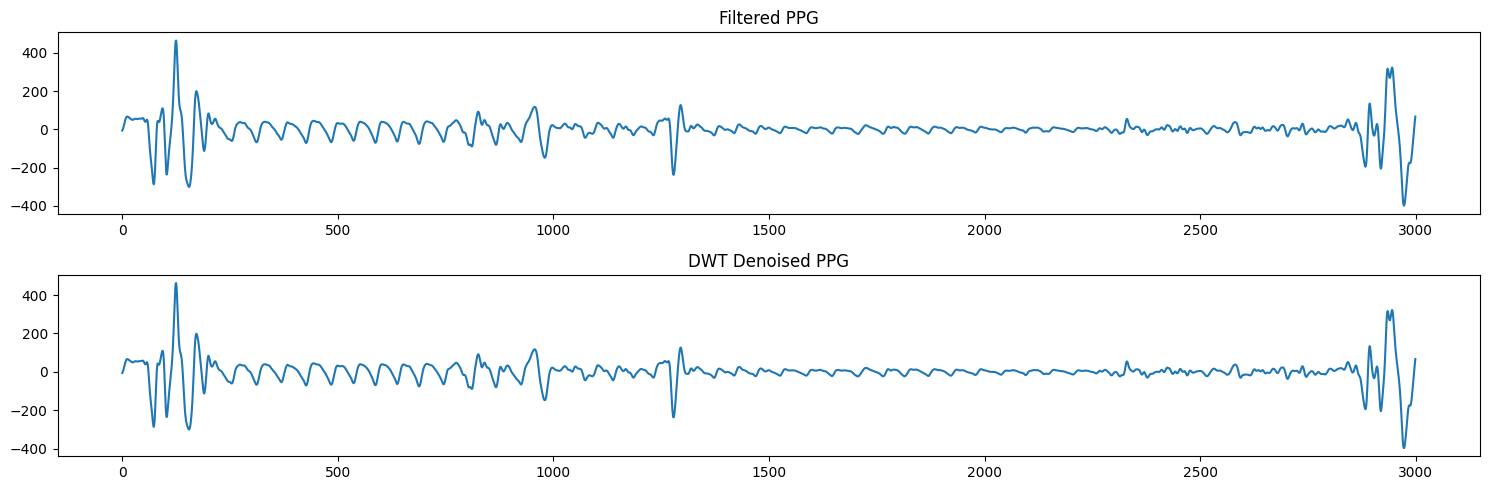

In [26]:
plt.figure(figsize=(15,5))

plt.subplot(2,1,1)
plt.plot(ppg_filtered[:3000])
plt.title("Filtered PPG")

plt.subplot(2,1,2)
plt.plot(ppg_denoised[:3000])
plt.title("DWT Denoised PPG")

plt.tight_layout()
plt.show()

In [27]:
print("Raw PPG")
print(np.std(ppg))

print("\nFiltered PPG")
print(np.std(ppg_filtered))

print("\nDenoised PPG")
print(np.std(ppg_denoised))

Raw PPG
75.87123615470419

Filtered PPG
71.35474835770562

Denoised PPG
71.28580974351455


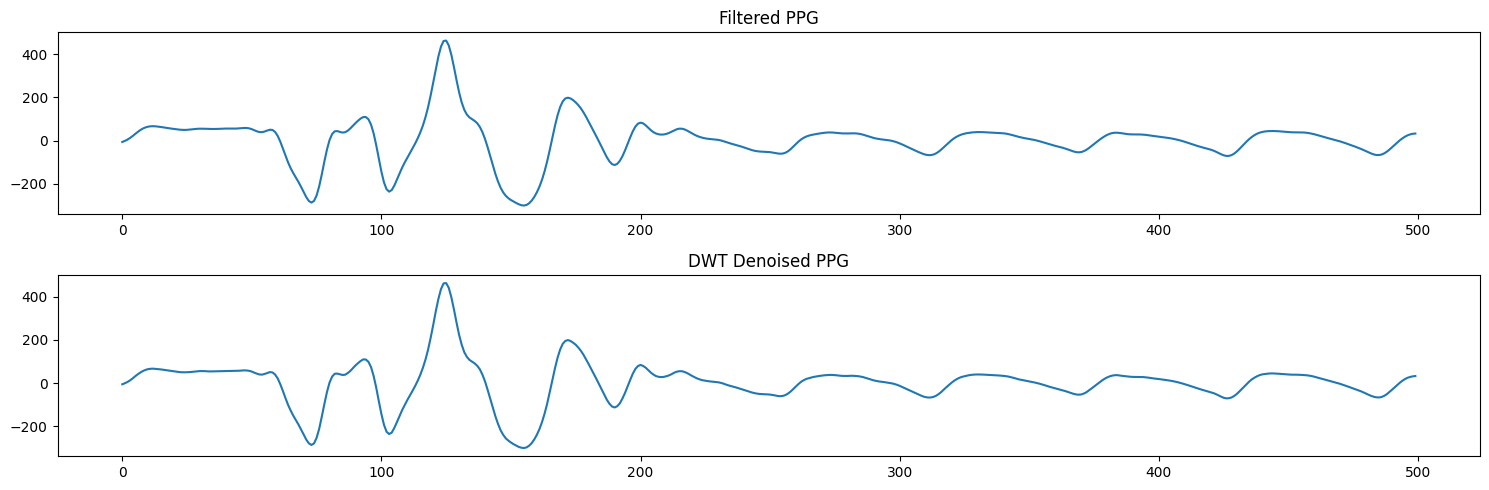

In [28]:

plt.figure(figsize=(15,5))

plt.subplot(2,1,1)
plt.plot(ppg_filtered[:500])
plt.title("Filtered PPG")

plt.subplot(2,1,2)
plt.plot(ppg_denoised[:500])
plt.title("DWT Denoised PPG")

plt.tight_layout()
plt.show()

In [29]:
difference = np.mean(np.abs(ppg_filtered - ppg_denoised))
print("Average Difference:", difference)

Average Difference: 0.24630188678413656


##  EDA Processing

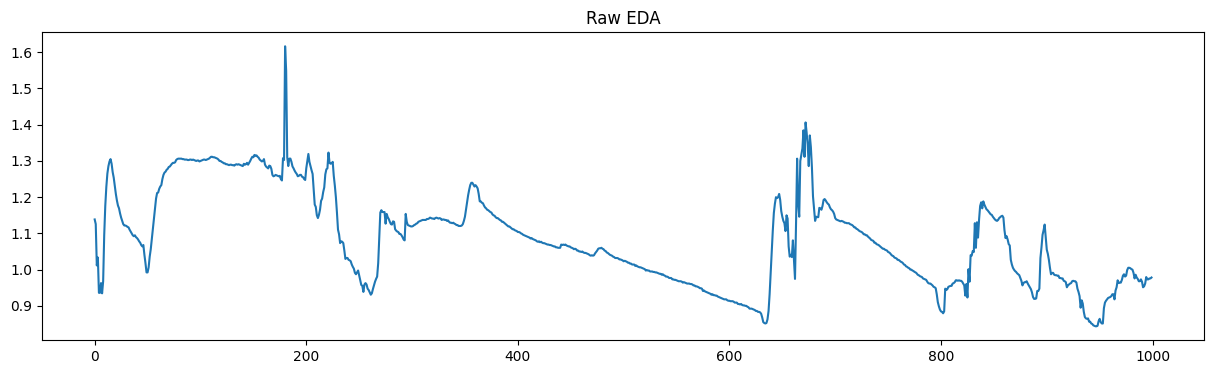

In [30]:
plt.figure(figsize=(15,4))
plt.plot(eda[:1000])
plt.title("Raw EDA")
plt.show()

In [31]:
signals, info = nk.eda_process(
    eda,
    sampling_rate=4
)

print(signals.columns)

c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


Index(['EDA_Raw', 'EDA_Clean', 'EDA_Tonic', 'EDA_Phasic', 'SCR_Onsets',
       'SCR_Peaks', 'SCR_Height', 'SCR_Amplitude', 'SCR_RiseTime',
       'SCR_Recovery', 'SCR_RecoveryTime'],
      dtype='object')


In [32]:
eda_clean = signals["EDA_Clean"]
eda_tonic = signals["EDA_Tonic"]
eda_phasic = signals["EDA_Phasic"]

print(eda_clean.shape)
print(eda_tonic.shape)
print(eda_phasic.shape)

(24316,)
(24316,)
(24316,)


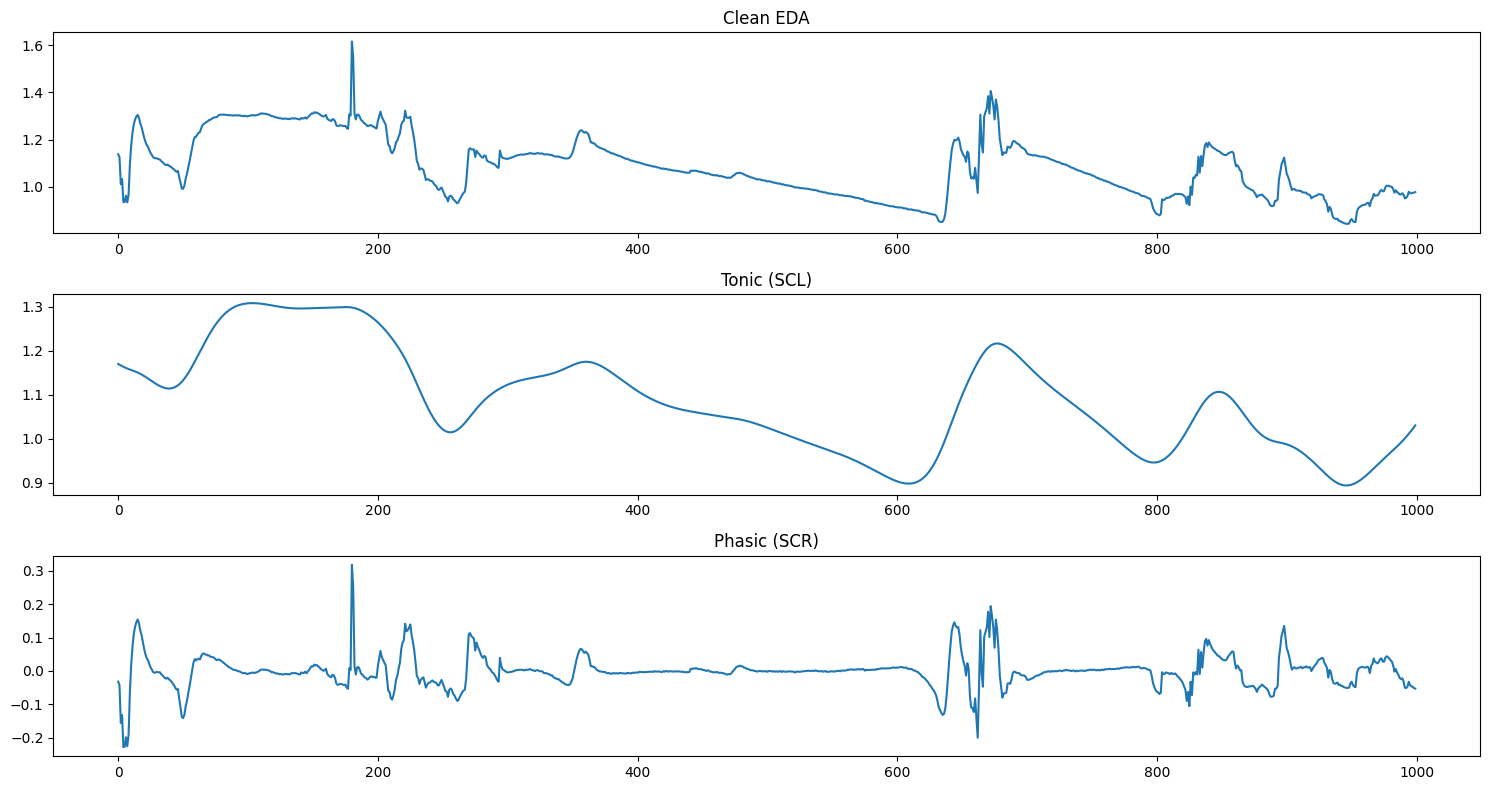

In [33]:
plt.figure(figsize=(15,8))

plt.subplot(3,1,1)
plt.plot(eda_clean[:1000])
plt.title("Clean EDA")

plt.subplot(3,1,2)
plt.plot(eda_tonic[:1000])
plt.title("Tonic (SCL)")

plt.subplot(3,1,3)
plt.plot(eda_phasic[:1000])
plt.title("Phasic (SCR)")

plt.tight_layout()
plt.show()

In [34]:
unique_labels = np.unique(labels)

print(unique_labels)

[0 1 2 3 4 6 7]


In [35]:
changes = np.where(
    np.diff(labels) != 0
)[0]

print(
    "Number of label changes:",
    len(changes)
)

Number of label changes: 14


In [36]:
segments = []

start = 0
current_label = labels[0]

for i in range(1, len(labels)):

    if labels[i] != current_label:

        segments.append(
            (
                current_label,
                start,
                i-1
            )
        )

        start = i
        current_label = labels[i]

segments.append(
    (
        current_label,
        start,
        len(labels)-1
    )
)

In [37]:
for seg in segments:

    label, start, end = seg

    duration = (
        end - start + 1
    ) / 700

    print(
        f"Label {label} | "
        f"{start} -> {end} | "
        f"{duration:.1f} sec"
    )

Label 0 | 0 -> 214582 | 306.5 sec
Label 1 | 214583 -> 1015382 | 1144.0 sec
Label 0 | 1015383 -> 1591481 | 823.0 sec
Label 2 | 1591482 -> 2021981 | 615.0 sec
Label 0 | 2021982 -> 2212382 | 272.0 sec
Label 6 | 2212383 -> 2257882 | 65.0 sec
Label 0 | 2257883 -> 2868282 | 872.0 sec
Label 4 | 2868283 -> 3141981 | 391.0 sec
Label 0 | 3141982 -> 3334482 | 275.0 sec
Label 3 | 3334483 -> 3587882 | 362.0 sec
Label 0 | 3587883 -> 3688682 | 144.0 sec
Label 7 | 3688683 -> 3733482 | 64.0 sec
Label 0 | 3733483 -> 3847582 | 163.0 sec
Label 4 | 3847583 -> 4111482 | 377.0 sec
Label 0 | 4111483 -> 4255299 | 205.5 sec


In [38]:
valid_segments = [
    (1,214583,1015382),
    (2,1591482,2021981),
    (4,2868283,3141981),
    (3,3334483,3587882),
    (4,3847583,4111482)
]

print("Valid Segments:", len(valid_segments))

Valid Segments: 5


In [39]:
WINDOW_SEC = 60

FS_ECG = 700
FS_PPG = 64
FS_EDA = 4

ECG_WIN = WINDOW_SEC * FS_ECG
PPG_WIN = WINDOW_SEC * FS_PPG
EDA_WIN = WINDOW_SEC * FS_EDA

print("ECG Window:", ECG_WIN)
print("PPG Window:", PPG_WIN)
print("EDA Window:", EDA_WIN)

ECG Window: 42000
PPG Window: 3840
EDA Window: 240


In [40]:
for label, start, end in valid_segments:

    segment_length = end - start + 1

    n_windows = segment_length // ECG_WIN

    print(
        f"Label {label}:",
        n_windows,
        "windows"
    )

Label 1: 19 windows
Label 2: 10 windows
Label 4: 6 windows
Label 3: 6 windows
Label 4: 6 windows


In [41]:
ecg_windows = []
ppg_windows = []
eda_windows = []

window_labels = []

In [42]:
for label, start, end in valid_segments:

    segment_length = end - start + 1

    n_windows = segment_length // ECG_WIN

    for w in range(n_windows):

        ecg_start = start + w * ECG_WIN
        ecg_end = ecg_start + ECG_WIN

        # ECG -> PPG index conversion
        ppg_start = int(ecg_start / 700 * 64)
        ppg_end = ppg_start + PPG_WIN

        # ECG -> EDA index conversion
        eda_start = int(ecg_start / 700 * 4)
        eda_end = eda_start + EDA_WIN

        ecg_seg = ecg_denoised[
            ecg_start:ecg_end
        ]

        ppg_seg = ppg_denoised[
            ppg_start:ppg_end
        ]

        eda_seg = eda[
            eda_start:eda_end
        ]

        if (
            len(ecg_seg) == ECG_WIN and
            len(ppg_seg) == PPG_WIN and
            len(eda_seg) == EDA_WIN
        ):

            ecg_windows.append(ecg_seg)
            ppg_windows.append(ppg_seg)
            eda_windows.append(eda_seg)

            window_labels.append(label)

In [ ]:
print(len(ecg_windows))
print(len(ppg_windows))
print(len(eda_windows))
print(len(window_labels))

47
47
47
47


In [44]:
print(ecg_windows[0].shape)
print(ppg_windows[0].shape)
print(eda_windows[0].shape)

(42000,)
(3840,)
(240,)


##  ECG Feature Extraction

In [45]:
import pandas as pd
import neurokit2 as nk
from scipy.signal import welch
from scipy.stats import entropy

In [46]:
def extract_ecg_features(ecg_window):

    try:

        _, info = nk.ecg_process(
            ecg_window,
            sampling_rate=700
        )

        r_peaks = info["ECG_R_Peaks"]

        rr = np.diff(r_peaks) / 700

        mean_rr = np.mean(rr)

        std_rr = np.std(rr)

        rmssd = np.sqrt(
            np.mean(np.diff(rr)**2)
        )

        heart_rate = 60 / mean_rr

        freqs, psd = welch(
            ecg_window,
            fs=700
        )

        dominant_freq = freqs[
            np.argmax(psd)
        ]

        hist, _ = np.histogram(
            ecg_window,
            bins=50,
            density=True
        )

        signal_entropy = entropy(hist)

        return {

            "mean_rr": mean_rr,
            "std_rr": std_rr,
            "rmssd": rmssd,
            "heart_rate": heart_rate,

            "ecg_mean": np.mean(ecg_window),
            "ecg_std": np.std(ecg_window),

            "ecg_min": np.min(ecg_window),
            "ecg_max": np.max(ecg_window),

            "ecg_skew":
            pd.Series(ecg_window).skew(),

            "ecg_kurt":
            pd.Series(ecg_window).kurt(),

            "dominant_freq":
            dominant_freq,

            "entropy":
            signal_entropy
        }

    except:

        return None

In [47]:
test_features = extract_ecg_features(
    ecg_windows[0]
)

print(test_features)

{'mean_rr': np.float64(0.7427857142857143), 'std_rr': np.float64(0.09588095829342397), 'rmssd': np.float64(0.06607261374236387), 'heart_rate': np.float64(80.77699778824888), 'ecg_mean': np.float64(0.00021460985111852957), 'ecg_std': np.float64(0.13690343399666638), 'ecg_min': np.float64(-0.36363501829453687), 'ecg_max': np.float64(0.7807399877016304), 'ecg_skew': np.float64(1.1824919920642094), 'ecg_kurt': np.float64(4.235145091388889), 'dominant_freq': np.float64(2.734375), 'entropy': np.float64(2.9086608064050012)}


In [48]:

ecg_feature_list = []

for window in ecg_windows:

    features = extract_ecg_features(
        window
    )

    if features is not None:

        ecg_feature_list.append(
            features
        )

In [49]:
ecg_df = pd.DataFrame(
    ecg_feature_list
)

print(ecg_df.shape)

ecg_df.head()

(47, 12)


,mean_rr,std_rr,rmssd,heart_rate,ecg_mean,ecg_std,ecg_min,ecg_max,ecg_skew,ecg_kurt,dominant_freq,entropy
0,0.742786,0.095881,0.066073,80.776998,0.000215,0.136903,-0.363635,0.780740,1.182492,4.235145,2.734375,2.908661
1,0.845280,0.074025,0.052348,70.982438,-0.000024,0.152708,-0.292590,0.799531,0.964518,3.810410,2.734375,2.782417
2,0.802231,0.074717,0.063790,74.791433,-0.000185,0.181864,-1.495659,1.449873,-0.141841,14.333854,2.734375,2.042082
3,0.829184,0.050756,0.052265,72.360325,0.000452,0.143133,-0.264122,0.722325,1.052820,3.884936,2.734375,2.757533
4,0.824366,0.059056,0.052334,72.783188,-0.000330,0.141984,-0.273651,0.725197,0.964136,3.539565,2.734375,2.767096


In [50]:
print(ecg_df.shape)

(47, 12)


## PPG Feature Extraction

In [51]:
def extract_ppg_features(ppg_window):

    try:

        signals, info = nk.ppg_process(
            ppg_window,
            sampling_rate=64
        )

        peaks = info["PPG_Peaks"]

        ibi = np.diff(peaks) / 64

        mean_ibi = np.mean(ibi)

        std_ibi = np.std(ibi)

        pulse_rate = 60 / mean_ibi

        pulse_var = np.var(ibi)

        freqs, psd = welch(
            ppg_window,
            fs=64
        )

        dominant_freq = freqs[
            np.argmax(psd)
        ]

        hist, _ = np.histogram(
            ppg_window,
            bins=50,
            density=True
        )

        signal_entropy = entropy(hist)

        return {

            "mean_ibi": mean_ibi,
            "std_ibi": std_ibi,
            "pulse_rate": pulse_rate,
            "pulse_var": pulse_var,

            "ppg_mean":
            np.mean(ppg_window),

            "ppg_std":
            np.std(ppg_window),

            "ppg_min":
            np.min(ppg_window),

            "ppg_max":
            np.max(ppg_window),

            "ppg_skew":
            pd.Series(ppg_window).skew(),

            "ppg_kurt":
            pd.Series(ppg_window).kurt(),

            "dominant_freq":
            dominant_freq,

            "entropy":
            signal_entropy
        }

    except:

        return None

In [52]:
ppg_feature_list = []

for window in ppg_windows:

    f = extract_ppg_features(
        window
    )

    if f is not None:

        ppg_feature_list.append(f)

In [53]:
ppg_df = pd.DataFrame(
    ppg_feature_list
)

print(ppg_df.shape)

ppg_df.head()

(47, 12)


,mean_ibi,std_ibi,pulse_rate,pulse_var,ppg_mean,ppg_std,ppg_min,ppg_max,ppg_skew,ppg_kurt,dominant_freq,entropy
0,0.708584,0.218069,84.675877,0.047554,0.278332,105.034748,-403.768976,502.775081,0.161816,2.818692,1.00,3.028394
1,0.779167,0.243113,77.005348,0.059104,-0.227877,44.418225,-274.507391,197.781257,-0.000716,6.336106,1.00,2.688072
2,0.805865,0.168126,74.454183,0.028266,0.255764,80.514930,-642.059770,375.258171,-1.356546,11.204104,1.00,2.235219
3,0.796242,0.176915,75.354018,0.031299,-0.018571,42.837382,-220.050043,277.235492,0.137599,7.932255,1.25,2.616915
4,0.804470,0.138462,74.583221,0.019172,-0.107007,44.119467,-503.351489,363.564623,-0.107861,45.575416,1.25,1.722953


##  EDA Feature Extraction

In [54]:
def extract_eda_features(eda_window):

    try:

        signals, info = nk.eda_process(
            eda_window,
            sampling_rate=4
        )

        tonic = signals["EDA_Tonic"]
        phasic = signals["EDA_Phasic"]

        freqs, psd = welch(
            eda_window,
            fs=4,
            nperseg=len(eda_window)
        )

        dominant_freq = freqs[
            np.argmax(psd)
        ]

        hist, _ = np.histogram(
            eda_window,
            bins=50,
            density=True
        )

        signal_entropy = entropy(hist)

        return {

            "eda_mean":
            np.mean(eda_window),

            "eda_std":
            np.std(eda_window),

            "eda_min":
            np.min(eda_window),

            "eda_max":
            np.max(eda_window),

            "eda_skew":
            pd.Series(eda_window).skew(),

            "eda_kurt":
            pd.Series(eda_window).kurt(),

            "tonic_mean":
            np.mean(tonic),

            "tonic_std":
            np.std(tonic),

            "phasic_mean":
            np.mean(phasic),

            "phasic_std":
            np.std(phasic),

            "dominant_freq":
            dominant_freq,

            "entropy":
            signal_entropy
        }

    except:

        return None

In [55]:
eda_feature_list = []

for window in eda_windows:

    f = extract_eda_features(window)

    if f is not None:

        eda_feature_list.append(f)

c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  w

In [56]:
print(len(eda_feature_list))

47


In [57]:
eda_df = pd.DataFrame(eda_feature_list)

print(eda_df.shape)

(47, 12)


In [58]:
feature_df = pd.concat(
    [ecg_df, ppg_df, eda_df],
    axis=1
)

feature_df["label"] = window_labels

print(feature_df.shape)

(47, 37)


In [59]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mean_rr        47 non-null     float64
 1   std_rr         47 non-null     float64
 2   rmssd          47 non-null     float64
 3   heart_rate     47 non-null     float64
 4   ecg_mean       47 non-null     float64
 5   ecg_std        47 non-null     float64
 6   ecg_min        47 non-null     float64
 7   ecg_max        47 non-null     float64
 8   ecg_skew       47 non-null     float64
 9   ecg_kurt       47 non-null     float64
 10  dominant_freq  47 non-null     float64
 11  entropy        47 non-null     float64
 12  mean_ibi       47 non-null     float64
 13  std_ibi        47 non-null     float64
 14  pulse_rate     47 non-null     float64
 15  pulse_var      47 non-null     float64
 16  ppg_mean       47 non-null     float64
 17  ppg_std        47 non-null     float64
 18  ppg_min     

In [60]:
feature_df["label"].value_counts()

label
1    19
4    12
2    10
3     6
Name: count, dtype: int64

In [61]:
feature_df.to_csv(
    "stress_features.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [62]:
import os

print(os.getcwd())

c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\notebooks


In [63]:
import os

os.path.exists("stress_features.csv")

True

In [64]:
import os

os.makedirs("../data/processed", exist_ok=True)

In [65]:
feature_df.to_csv(
    "../data/processed/stress_features.csv",
    index=False
)

In [66]:
feature_df.to_csv(
    "stress_features.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [67]:
print(feature_df.shape)
print(feature_df["label"].value_counts())

(47, 37)
label
1    19
4    12
2    10
3     6
Name: count, dtype: int64


In [68]:
feature_df.isnull().sum()

mean_rr          0
std_rr           0
rmssd            0
heart_rate       0
ecg_mean         0
ecg_std          0
ecg_min          0
ecg_max          0
ecg_skew         0
ecg_kurt         0
dominant_freq    0
entropy          0
mean_ibi         0
std_ibi          0
pulse_rate       0
pulse_var        0
ppg_mean         0
ppg_std          0
ppg_min          0
ppg_max          0
ppg_skew         0
ppg_kurt         0
dominant_freq    0
entropy          0
eda_mean         0
eda_std          0
eda_min          0
eda_max          0
eda_skew         0
eda_kurt         0
tonic_mean       0
tonic_std        0
phasic_mean      0
phasic_std       0
dominant_freq    0
entropy          0
label            0
dtype: int64

In [69]:
print(ecg_df.columns.tolist())
print(ppg_df.columns.tolist())
print(eda_df.columns.tolist())

['mean_rr', 'std_rr', 'rmssd', 'heart_rate', 'ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max', 'ecg_skew', 'ecg_kurt', 'dominant_freq', 'entropy']
['mean_ibi', 'std_ibi', 'pulse_rate', 'pulse_var', 'ppg_mean', 'ppg_std', 'ppg_min', 'ppg_max', 'ppg_skew', 'ppg_kurt', 'dominant_freq', 'entropy']
['eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_skew', 'eda_kurt', 'tonic_mean', 'tonic_std', 'phasic_mean', 'phasic_std', 'dominant_freq', 'entropy']


In [70]:
ecg_df = ecg_df.add_prefix("ecg_")
ppg_df = ppg_df.add_prefix("ppg_")
eda_df = eda_df.add_prefix("eda_")

In [71]:
print(ecg_df.columns[:5])
print(ppg_df.columns[:5])
print(eda_df.columns[:5])

Index(['ecg_mean_rr', 'ecg_std_rr', 'ecg_rmssd', 'ecg_heart_rate',
       'ecg_ecg_mean'],
      dtype='object')
Index(['ppg_mean_ibi', 'ppg_std_ibi', 'ppg_pulse_rate', 'ppg_pulse_var',
       'ppg_ppg_mean'],
      dtype='object')
Index(['eda_eda_mean', 'eda_eda_std', 'eda_eda_min', 'eda_eda_max',
       'eda_eda_skew'],
      dtype='object')


In [72]:
feature_df = pd.concat(
    [ecg_df, ppg_df, eda_df],
    axis=1
)

feature_df["label"] = window_labels

print(feature_df.shape)

(47, 37)


In [73]:
X = feature_df.drop("label", axis=1)
y = feature_df["label"]

print(X.shape)

(47, 36)


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Training Complete")

Training Complete


In [76]:
rf.fit(X_train, y_train)

print("Training Complete")

Training Complete


In [77]:
y_pred = rf.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 4 2 1 1 4 3 2 1 1]


In [78]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Accuracy =", acc)

Accuracy = 0.9


In [79]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           1       0.80      1.00      0.89         4
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       1.00      0.67      0.80         3

    accuracy                           0.90        10
   macro avg       0.95      0.92      0.92        10
weighted avg       0.92      0.90      0.90        10



In [80]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4 0 0 0]
 [0 2 0 0]
 [0 0 1 0]
 [1 0 0 2]]


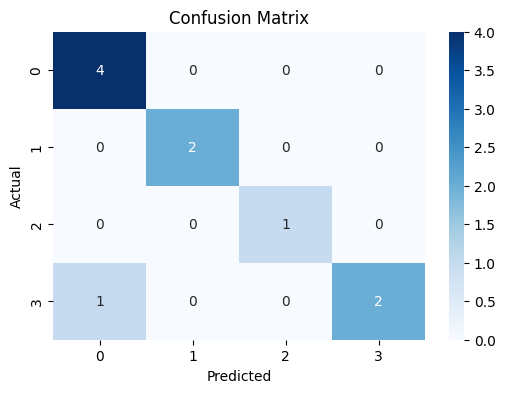

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [82]:
import os

dataset_path = r"C:\Users\AMRITHA\OneDrive\Desktop\stress_classification\data\WESAD"

print(os.listdir(dataset_path))

['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'wesad_readme.pdf']


In [83]:
subjects = [
    "S2","S3","S4","S5","S6",
    "S7","S8","S9","S10","S11",
    "S13","S14","S15","S16","S17"
]

print("Total Subjects:", len(subjects))

Total Subjects: 15


In [84]:
import pickle
import os

for subject in subjects:

    file_path = f"../data/WESAD/{subject}/{subject}.pkl"

    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    print(subject, "Loaded")

S2 Loaded
S3 Loaded
S4 Loaded
S5 Loaded
S6 Loaded
S7 Loaded
S8 Loaded
S9 Loaded
S10 Loaded
S11 Loaded
S13 Loaded
S14 Loaded
S15 Loaded
S16 Loaded
S17 Loaded


In [85]:
%who function

accuracy_score	 bandpass_filter	 butter	 classification_report	 confusion_matrix	 entropy	 extract_ecg_features	 extract_eda_features	 extract_ppg_features	 
filtfilt	 train_test_split	 wavelet_denoise	 welch	 


In [86]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', 'os', '_i3', 'dataset_path', '_i4', '_i5', 'pickle', 'file_path', 'f', 'data', '_i6', '_i7', '_i8', '_i9', 'ECG', 'PPG', 'EDA', 'labels', '_i10', 'nk', '_i11', 'np', 'pd', 'plt', 'butter', 'filtfilt', 'welch', 'entropy', '_i12', '_i13', 'ecg', 'ppg', 'eda', '_i14', '_i15', 'bandpass_filter', '_i16', 'ecg_filtered', '_i17', '_i18', 'pywt', '_i19', 'wavelet_denoise', '_i20', 'ecg_denoised', '_i21', '_i22', '_i23', 'ppg_filtered', '_i24', '_i25', 'ppg_denoised', '_i26', '_i27', '_i28', '_i29', 'difference', '_i30', '_i31', 'signals', 'info', '_i32', 'eda_clean', 'eda_tonic', 'eda_phasic', '_i33', '_i34', 'unique_labels', '_i35', 'changes', '_i36', 'segments', 'start', 'current_label', 'i', '_i37', 'seg', 'label', 'end', 'duration', '_i38',

In [87]:
print(X.shape)
print(y.shape)
print(subjects.shape)

(47, 36)
(47,)


AttributeError: 'list' object has no attribute 'shape'

In [88]:
print(type(subjects))
print(len(subjects))
print(subjects[:10])

<class 'list'>
15
['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11']


In [89]:
print(len(subjects))
print(X.shape[0])
print(len(y))

15
47
47


In [90]:
subjects = [
    'S2','S3','S4','S5',
    'S6','S7','S8','S9',
    'S10','S11','S13',
    'S14','S15','S16','S17'
]

In [91]:
all_features = []
all_labels = []
subject_ids = []

In [92]:
def process_subject(subject):

    print(f"Processing {subject}...")

    file_path = f"../data/WESAD/{subject}/{subject}.pkl"

    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    ecg = data['signal']['chest']['ECG'].flatten()
    ppg = data['signal']['wrist']['BVP'].flatten()
    eda = data['signal']['wrist']['EDA'].flatten()
    labels = data['label'].flatten()
    return [], []

In [93]:
    ecg_filtered = bandpass_filter(
        ecg,
        lowcut=0.5,
        highcut=40,
        fs=700
    )

    ecg_denoised = wavelet_denoise(ecg_filtered)

    ppg_filtered = bandpass_filter(
        ppg,
        lowcut=0.5,
        highcut=8,
        fs=64
    )

    ppg_denoised = wavelet_denoise(ppg_filtered)

In [94]:
    signals, info = nk.eda_process(
        eda,
        sampling_rate=4
    )

    eda_clean = signals["EDA_Clean"]
    tonic = signals["EDA_Tonic"]
    phasic = signals["EDA_Phasic"]

c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


In [95]:
print(len(window_labels))

47


In [96]:
    subject_features = []
    subject_labels = []

In [97]:
    for i in range(len(window_labels)):

        ecg_feat = extract_ecg_features(
            ecg_windows[i]
        )

        ppg_feat = extract_ppg_features(
            ppg_windows[i]
        )

        eda_feat = extract_eda_features(
            eda_windows[i]
        )

        if (
            ecg_feat is not None and
            ppg_feat is not None and
            eda_feat is not None
        ):

            combined = {
                **ecg_feat,
                **ppg_feat,
                **eda_feat
            }

            subject_features.append(combined)
            subject_labels.append(window_labels[i])

c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
c:\Users\AMRITHA\OneDrive\Desktop\stress_classification\venv\Lib\site-packages\neurokit2\eda\eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  w

In [ ]:
all_features = []
all_labels = []
subject_ids = []

In [ ]:
for subject in subjects:

    features, labels = process_subject(subject)

    all_features.extend(features)

    all_labels.extend(labels)

    subject_ids.extend(
        [subject] * len(labels)
    )

    print(
        subject,
        len(labels)
    )

Processing S2...
S2 0
Processing S3...
S3 0
Processing S4...
S4 0
Processing S5...
S5 0
Processing S6...
S6 0
Processing S7...
S7 0
Processing S8...
S8 0
Processing S9...
S9 0
Processing S10...
S10 0
Processing S11...
S11 0
Processing S13...
S13 0
Processing S14...
S14 0
Processing S15...
S15 0
Processing S16...
S16 0
Processing S17...
S17 0


In [ ]:
result = process_subject("S2")

print(result)

Processing S2...
None


In [98]:
print(feature_df.shape)

(47, 37)


In [99]:
print(X.shape)

(47, 36)


In [100]:
print(y.shape)

(47,)


In [101]:
print(feature_df.head())

   ecg_mean_rr  ecg_std_rr  ecg_rmssd  ecg_heart_rate  ecg_ecg_mean  \
0     0.742786    0.095881   0.066073       80.776998      0.000215   
1     0.845280    0.074025   0.052348       70.982438     -0.000024   
2     0.802231    0.074717   0.063790       74.791433     -0.000185   
3     0.829184    0.050756   0.052265       72.360325      0.000452   
4     0.824366    0.059056   0.052334       72.783188     -0.000330   

   ecg_ecg_std  ecg_ecg_min  ecg_ecg_max  ecg_ecg_skew  ecg_ecg_kurt  ...  \
0     0.136903    -0.363635     0.780740      1.182492      4.235145  ...   
1     0.152708    -0.292590     0.799531      0.964518      3.810410  ...   
2     0.181864    -1.495659     1.449873     -0.141841     14.333854  ...   
3     0.143133    -0.264122     0.722325      1.052820      3.884936  ...   
4     0.141984    -0.273651     0.725197      0.964136      3.539565  ...   

   eda_eda_max  eda_eda_skew  eda_eda_kurt  eda_tonic_mean  eda_tonic_std  \
0     1.645664      0.477792     

In [102]:
print(extract_ecg_features)
print(extract_ppg_features)
print(extract_eda_features)

<function extract_ecg_features at 0x000001D221394B80>
<function extract_ppg_features at 0x000001D22132AAC0>
<function extract_eda_features at 0x000001D22132A980>


In [103]:
print(bandpass_filter)
print(wavelet_denoise)

<function bandpass_filter at 0x000001D21BC5B1A0>
<function wavelet_denoise at 0x000001D21BC749A0>
